In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create required directories
os.makedirs('results', exist_ok=True)
os.makedirs('sample_predictions', exist_ok=True)

# ==========================================
# Task 1: Problem Identification
# ==========================================
print("Task 1: Problem Identification")
print("Problem Type: Image Classification.")
print("Reason: We are given whole images of products and need to classify each into one of four distinct, mutually exclusive categories (normal, scratch, dent, stain). We are not required to draw bounding boxes (Object Detection) or highlight exact pixel boundaries (Segmentation).\n")

Task 1: Problem Identification
Problem Type: Image Classification.
Reason: We are given whole images of products and need to classify each into one of four distinct, mutually exclusive categories (normal, scratch, dent, stain). We are not required to draw bounding boxes (Object Detection) or highlight exact pixel boundaries (Segmentation).



Task 2: Dataset Exploration
Total images in dataset: 480
Class Distribution:
class
normal     120
stain      120
dent       120
scratch    120
Name: count, dtype: int64


C:\Users\Vivek Vishwakarma\AppData\Local\Temp\ipykernel_29924\974763981.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


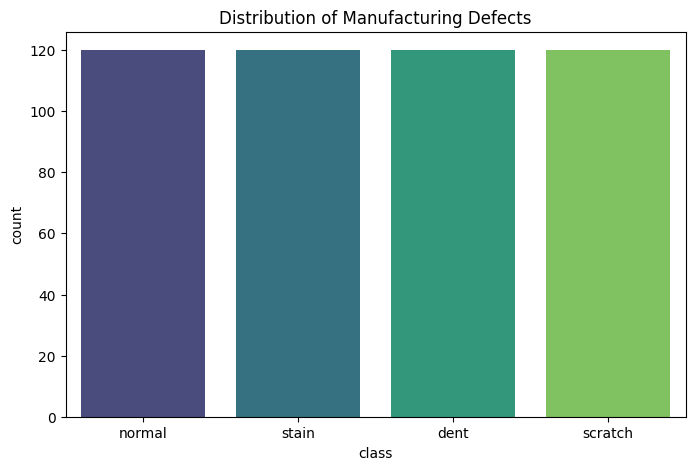

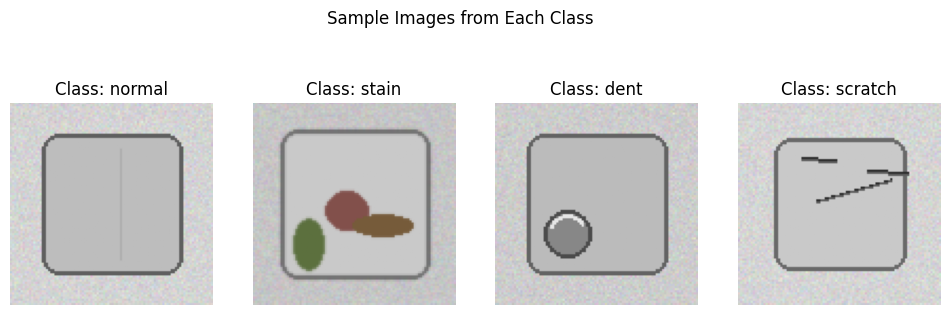

In [6]:
# ==========================================
# Task 2: Dataset Exploration
# ==========================================
print("Task 2: Dataset Exploration")
df = pd.read_csv('labels.csv')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total images in dataset: {len(df)}")
print("Class Distribution:")
print(df['class'].value_counts())

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='class', data=df, palette='viridis')
plt.title('Distribution of Manufacturing Defects')
plt.show()

# Show sample images (one from each class)
plt.figure(figsize=(12, 4))
unique_classes = df['class'].unique()
for i, cls in enumerate(unique_classes):
    # Get first image path for the class
    sample_path = df[df['class'] == cls].iloc[0]['filename']
    img = mpimg.imread(sample_path)
    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}")
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

In [7]:
# ==========================================
# Task 3: Image Preprocessing
# ==========================================
print("\nTask 3: Image Preprocessing")
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Data Augmentation for training, simple rescaling for validation
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Normalize pixels between 0 and 1
    validation_split=0.2,    # 80/20 train/test split
    rotation_range=15,       # Data augmentation (rotate)
    width_shift_range=0.1,   # Data augmentation (shift)
    height_shift_range=0.1,  
    horizontal_flip=True     # Data augmentation (flip)
)

print("Preparing Training Set:")
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory='.',           # Root directory since paths in CSV include 'images/...'
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

print("Preparing Validation Set:")
val_generator = train_datagen.flow_from_dataframe(
    dataframe=df,
    directory='.',
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False # Crucial for accurate confusion matrix later!
)


Task 3: Image Preprocessing
Preparing Training Set:
Found 384 validated image filenames belonging to 4 classes.
Preparing Validation Set:
Found 96 validated image filenames belonging to 4 classes.


In [8]:
# ==========================================
# Task 4: CNN Model Creation
# ==========================================
print("\nTask 4: CNN Model Creation")
model = Sequential([
    # Convolution Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    MaxPooling2D((2, 2)),
    
    # Convolution Block 2
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Convolution Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Transition to Dense Layers
    Flatten(),
    
    # Fully Connected Layer
    Dense(128, activation='relu'),
    Dropout(0.3), # Prevent overfitting
    
    # Output Layer (4 classes -> Softmax)
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Task 4: CNN Model Creation


c:\Users\Vivek Vishwakarma\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


Task 5: Model Training
Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.2812 - loss: 1.4504 - val_accuracy: 0.1875 - val_loss: 1.3906
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - accuracy: 0.2448 - loss: 1.3868 - val_accuracy: 0.1979 - val_loss: 1.3850
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - accuracy: 0.2578 - loss: 1.3683 - val_accuracy: 0.4062 - val_loss: 1.3258
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 153ms/step - accuracy: 0.3932 - loss: 1.2769 - val_accuracy: 0.3750 - val_loss: 1.3031
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 0.4688 - loss: 1.1327 - val_accuracy: 0.6979 - val_loss: 0.8753
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.5990 - loss: 0.9079 - val_accuracy: 0.7708 - val_loss: 0.6693
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.7161 - loss: 0.7164 - val_accuracy: 0.7708 - val_loss: 0.5941
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.7917 - loss: 0

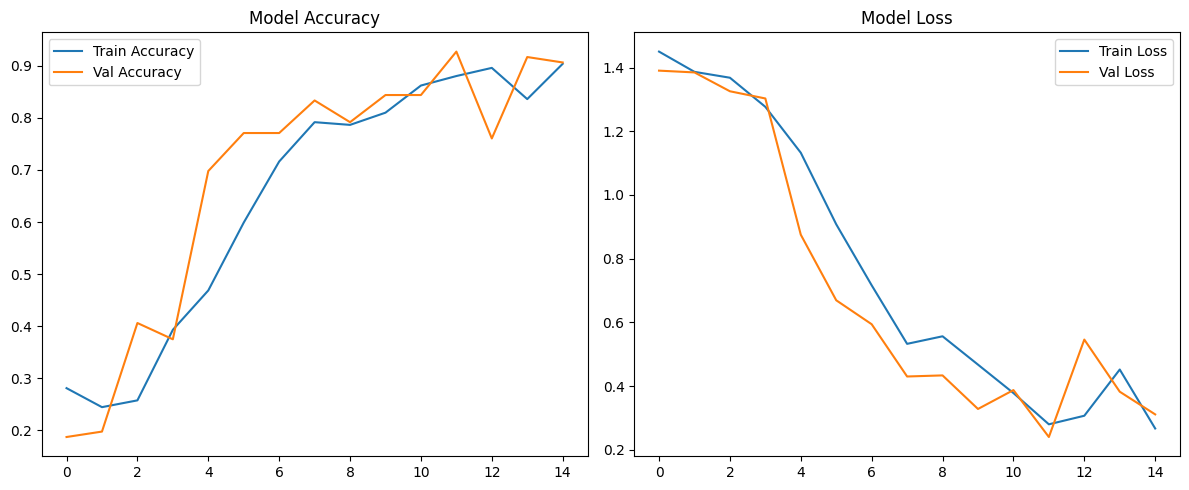


Generating Confusion Matrix...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


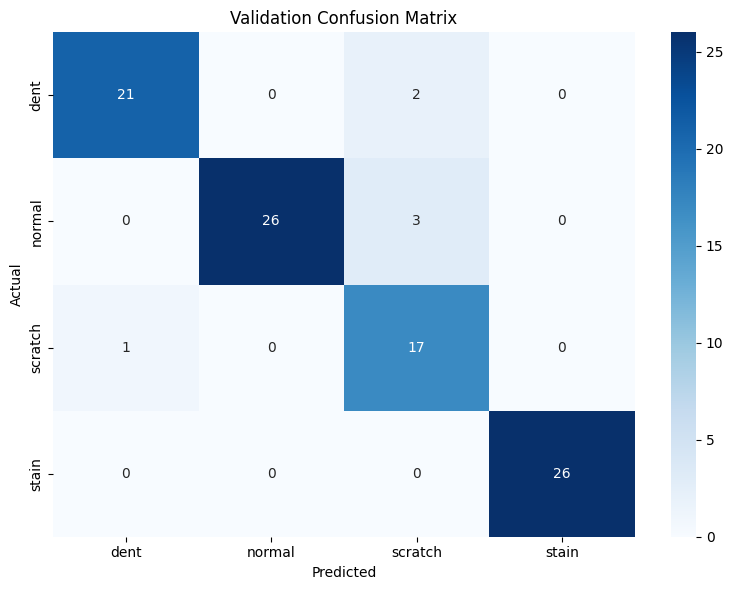


Classification Report:
              precision    recall  f1-score   support

        dent       0.95      0.91      0.93        23
      normal       1.00      0.90      0.95        29
     scratch       0.77      0.94      0.85        18
       stain       1.00      1.00      1.00        26

    accuracy                           0.94        96
   macro avg       0.93      0.94      0.93        96
weighted avg       0.95      0.94      0.94        96


Generating Sample Predictions...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


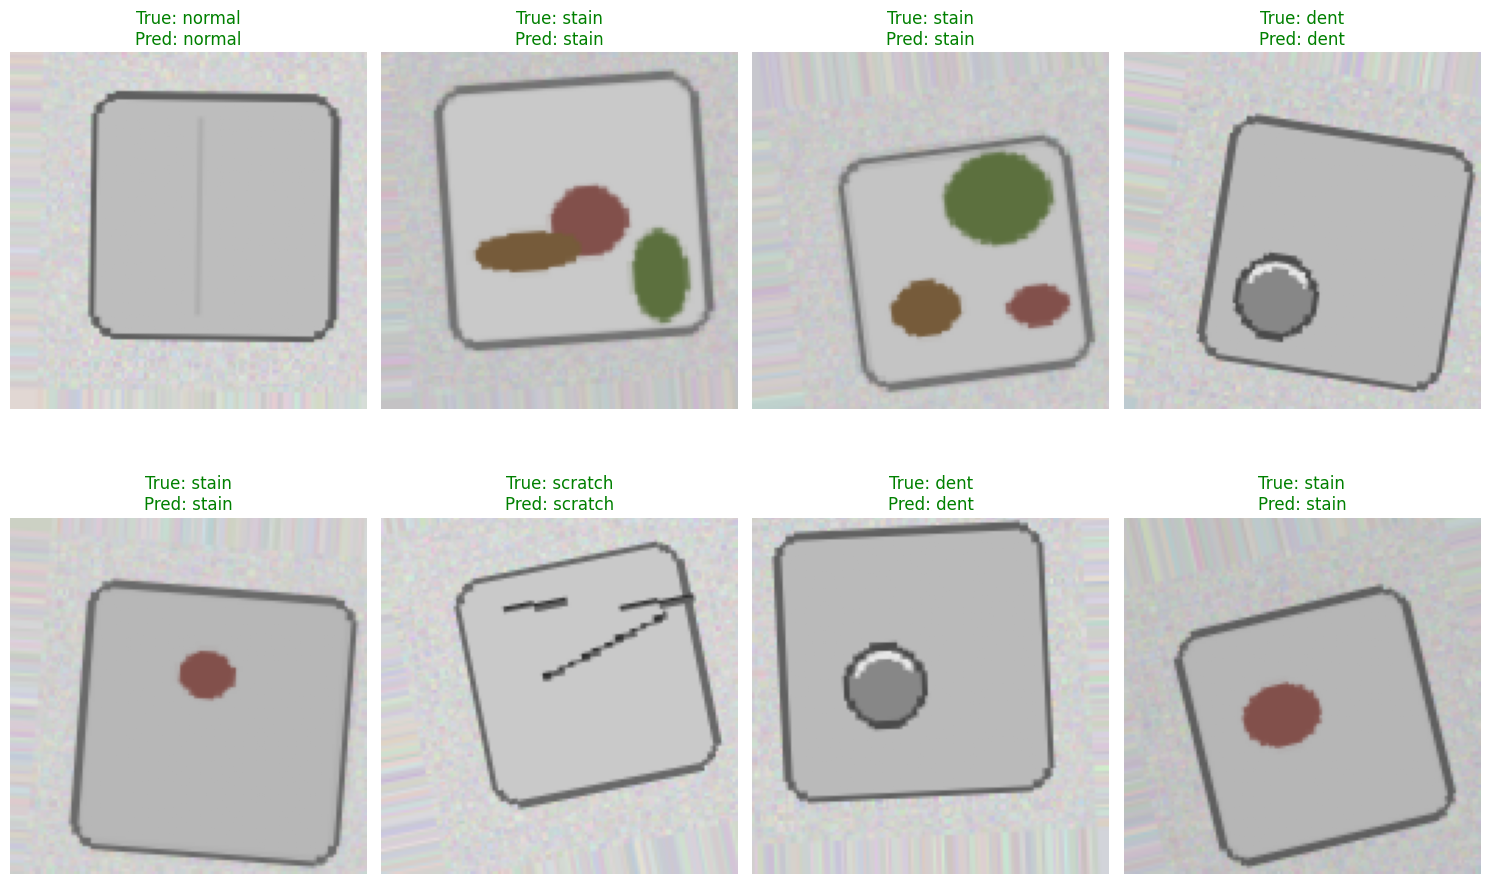

Process Complete! Images saved to 'results' and 'sample_predictions' folders.


In [9]:
# ==========================================
# Task 5: Model Training and Evaluation
# ==========================================
print("\nTask 5: Model Training")
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

# 1. Plot Accuracy & Loss Curves
plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.savefig('results/accuracy_loss_curves.png')
plt.show()

# 2. Confusion Matrix
print("\nGenerating Confusion Matrix...")
# Predict on validation data
y_pred_probs = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = val_generator.classes
class_labels = list(train_generator.class_indices.keys())

cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Validation Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_labels, labels=np.arange(len(class_labels))))

# 3. Sample Predictions Output
print("\nGenerating Sample Predictions...")
# Get one batch of validation images
val_images, val_labels_encoded = next(val_generator)
val_preds = model.predict(val_images)

plt.figure(figsize=(15, 10))
for i in range(min(8, len(val_images))): # Show up to 8 images
    plt.subplot(2, 4, i + 1)
    plt.imshow(val_images[i])
    
    true_class = class_labels[np.argmax(val_labels_encoded[i])]
    pred_class = class_labels[np.argmax(val_preds[i])]
    
    color = 'green' if true_class == pred_class else 'red'
    plt.title(f"True: {true_class}\nPred: {pred_class}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()
print("Process Complete! Images saved to 'results' and 'sample_predictions' folders.")